# 01 - EDA
EDA sobre el dataset procesado. No regenera datos desde raw.

In [ ]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("..") / "data" / "processed" / "final_dataset.csv"

df = pd.read_csv(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

# Mostrar las primeras filas del DataFrame
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,rank_home,...,market_value_eur_away,fifa_rank_away,top5_players_away,market_value_diff,avg_age_diff,squad_size_diff,top5_players_diff,rank_diff,years_ago,weight
0,1998-01-03,Malawi,Zimbabwe,1.0,0.0,Friendly,Blantyre,Malawi,False,97.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,28,0.001207
1,1998-01-04,Barbados,Trinidad and Tobago,0.0,1.0,Friendly,Bridgetown,Barbados,False,113.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.0,28,0.001207
2,1998-01-04,Burkina Faso,Mozambique,1.0,0.0,Friendly,Bobo Dioulasso,Burkina Faso,False,106.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.0,28,0.001207
3,1998-01-04,Guinea,Togo,1.0,0.0,Friendly,Conakry,Guinea,False,65.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-13.0,28,0.001207
4,1998-01-04,Malawi,Zimbabwe,0.0,2.0,Friendly,Lilongwe,Malawi,False,97.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.0,28,0.001207


In [ ]:
# Verificar tipos de datos
df.info()

# Verificar valores faltantes (NaN)
df.isna().mean().sort_values(ascending=False).head(10)

<class 'pandas.DataFrame'>
RangeIndex: 26733 entries, 0 to 26732
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   26733 non-null  datetime64[us]
 1   home_team              26733 non-null  str           
 2   away_team              26733 non-null  str           
 3   home_score             26733 non-null  float64       
 4   away_score             26733 non-null  float64       
 5   tournament             26733 non-null  str           
 6   city                   26733 non-null  str           
 7   country                26733 non-null  str           
 8   neutral                26733 non-null  bool          
 9   rank_home              26733 non-null  float64       
 10  rank_away              26733 non-null  float64       
 11  result                 26733 non-null  int64         
 12  squad_size_home        8523 non-null   float64       
 13  avg_age_home

top5_players_diff        0.848315
market_value_diff        0.848315
avg_age_diff             0.848315
squad_size_diff          0.848315
fifa_rank_away           0.720982
squad_size_away          0.720982
avg_age_away             0.720982
market_value_eur_away    0.720982
top5_players_away        0.720982
top5_players_home        0.681181
dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crear directorio para guardar figuras
FIG_DIR = Path("..") / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

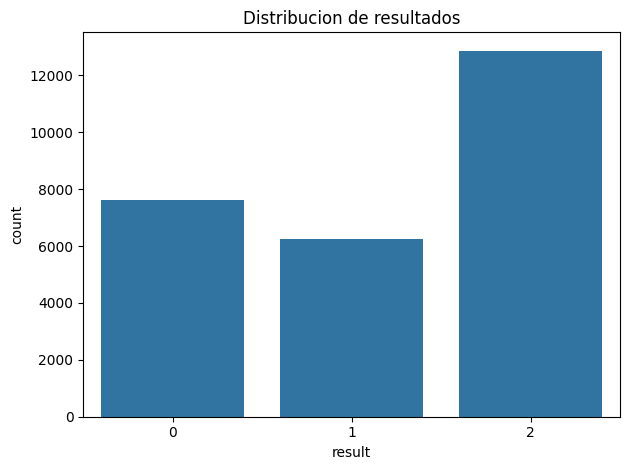

In [ ]:
# Distribución de resultados
# Resultados:
#   2 = Gana Local, 1 = Empate, 0 = Gana Visitante
sns.countplot(data=df, x="result")
plt.title("Distribucion de resultados")
plt.tight_layout()
plt.savefig(FIG_DIR / "dist_resultados.png", dpi=150)
plt.show()

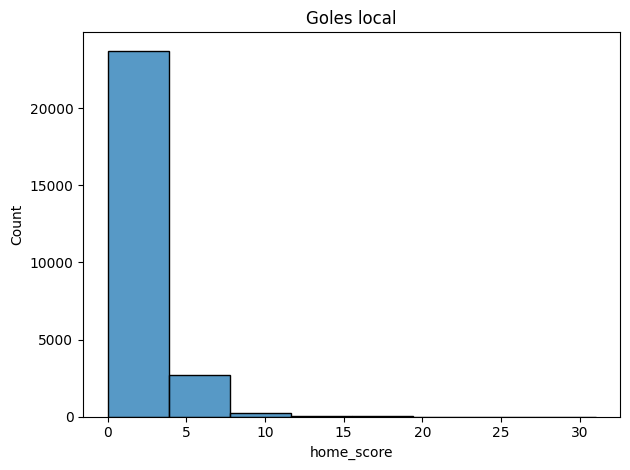

In [ ]:
# Distribución de goles locales
sns.histplot(df["home_score"], bins=8, kde=False)
plt.title("Goles local")
plt.tight_layout()
plt.savefig(FIG_DIR / "goles_local.png", dpi=150)
plt.show()

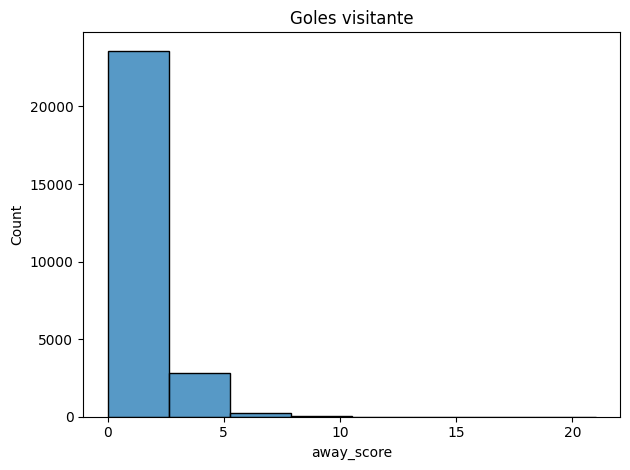

In [ ]:
# Distribución de goles visitantes
sns.histplot(df["away_score"], bins=8, kde=False)
plt.title("Goles visitante")
plt.tight_layout()
plt.savefig(FIG_DIR / "goles_visitante.png", dpi=150)
plt.show()

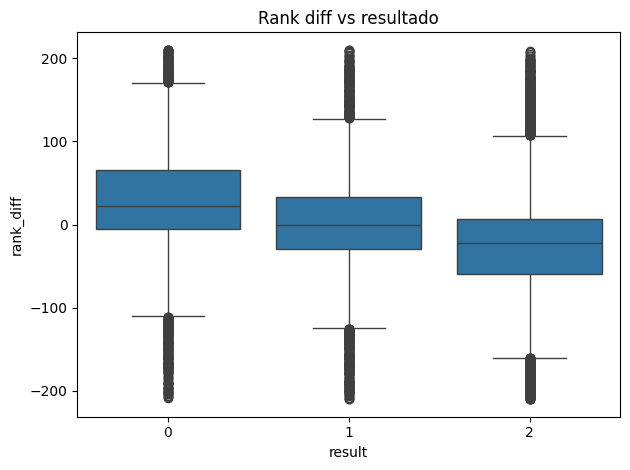

In [ ]:
# Distribución de la diferencia de goles (home_score - away_score)
sns.boxplot(data=df, x="result", y="rank_diff")
plt.title("Rank diff vs resultado")
plt.tight_layout()
plt.savefig(FIG_DIR / "rank_diff_vs_result.png", dpi=150)
plt.show()

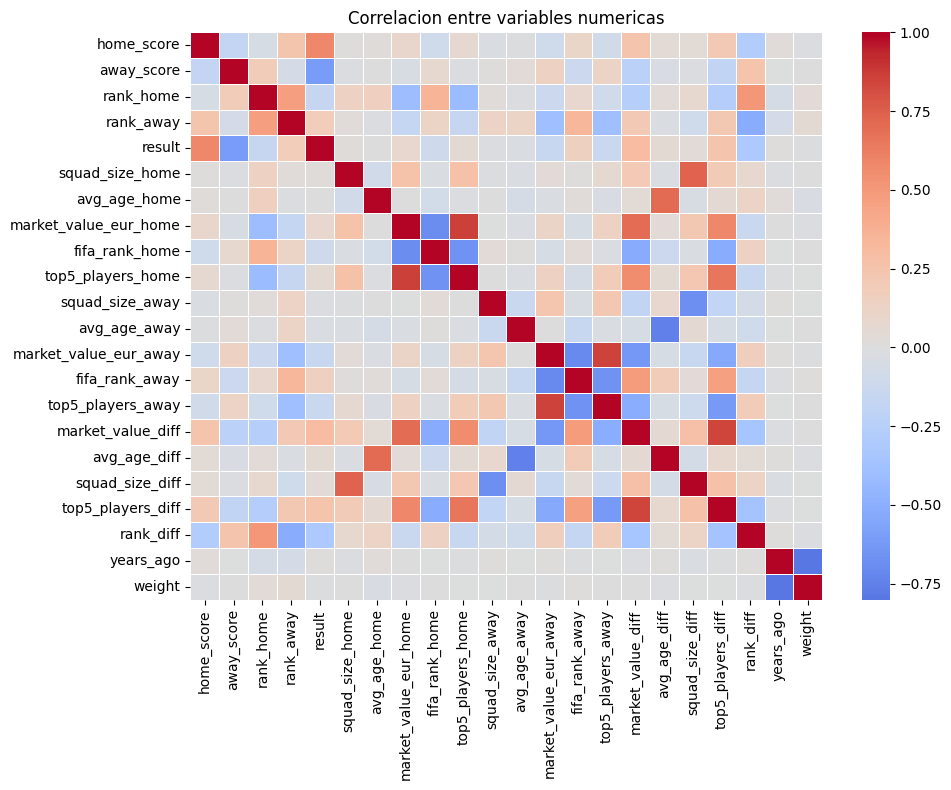

In [8]:
numeric_cols = df.select_dtypes(include="number").columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlacion entre variables numericas")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlacion_numericas.png", dpi=150)
plt.show()

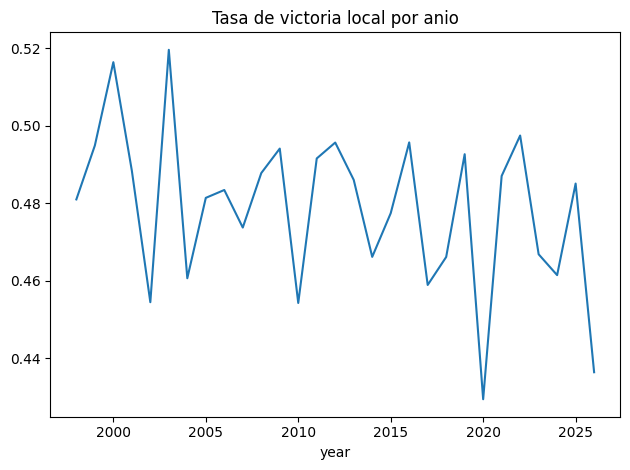

In [9]:
yearly = df.copy()
yearly["year"] = yearly["date"].dt.year
yearly["home_win"] = (yearly["result"] == 2).astype(int)

yearly.groupby("year")["home_win"].mean().plot()
plt.title("Tasa de victoria local por anio")
plt.tight_layout()
plt.savefig(FIG_DIR / "tasa_victoria_local_anual.png", dpi=150)
plt.show()